# Engineering fundamentals - small numerical experiments

Self-contained checks on the physics and numerics I lean on in the data
investigations: the lumped-capacitance assumption, transient integration
schemes and their stability / accuracy order, and 1-D conduction. No external
data. Each result is checked against a closed-form solution - a discretisation
earns trust by reproducing a case with a known answer before it is used for
anything new.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

## A1. Non-dimensional groups: Biot and Fourier

A solid body cooling in a fluid is governed by two numbers:

* **Biot** $Bi = hL_c/k$  -  ratio of internal conduction resistance to surface
  convection resistance. $Bi \ll 1$ means the body is nearly isothermal and a
  single-temperature ("lumped") model is legitimate.
* **Fourier** $Fo = \alpha t / L_c^2$  -  dimensionless time. The transient is
  essentially over by $Fo \approx 1$.

$L_c = V/A_s$ is the characteristic length. Below I check the lumped assumption
for a prismatic battery cell cooled on its faces.

In [2]:
# Prismatic cell, cooled on the two large faces.
W, H, Th = 0.148, 0.091, 0.0269       # m  (typical ~50 Ah prismatic)
k_cell = 0.9                           # W/m-K  through-plane (jelly roll is anisotropic)
rho_cell, cp_cell = 2400.0, 1000.0     # kg/m3, J/kg-K
alpha_cell = k_cell / (rho_cell * cp_cell)

A_faces = 2 * W * H
V_cell = W * H * Th
Lc = V_cell / A_faces                  # ~ Th/2 for face cooling

for h in [5, 25, 100, 400]:            # natural -> forced air -> liquid cold plate
    Bi = h * Lc / k_cell
    verdict = "lumped OK" if Bi < 0.1 else "needs spatial model"
    print(f"h={h:4d} W/m2K   Lc={Lc*1e3:5.2f} mm   Bi={Bi:6.3f}   -> {verdict}")

t63 = Lc**2 / alpha_cell               # time to Fo ~ 1 (order of magnitude)
print(f"\nthermal diffusion time (Fo=1): {t63/60:.1f} min")

h=   5 W/m2K   Lc=13.45 mm   Bi= 0.075   -> lumped OK
h=  25 W/m2K   Lc=13.45 mm   Bi= 0.374   -> needs spatial model
h= 100 W/m2K   Lc=13.45 mm   Bi= 1.494   -> needs spatial model
h= 400 W/m2K   Lc=13.45 mm   Bi= 5.978   -> needs spatial model

thermal diffusion time (Fo=1): 8.0 min


So an air-cooled cell can be treated as a single lump; a cold-plate-cooled cell
cannot  -  the through-plane gradient matters. That is exactly why the Modelica
cell model in my `BatteryTR` library splits the cell into a few through-plane
nodes instead of one.

## A2. Transient lumped capacitance  -  analytic vs numerical

Energy balance on an isothermal lump with convective loss:

$$ \rho V c_p \frac{dT}{dt} = \dot Q_{gen} - h A_s (T - T_\infty) $$

With constant $\dot Q_{gen}$ the exact solution is a first-order approach to the
steady value $T_\infty + \dot Q_{gen}/(hA_s)$ with time constant
$\tau = \rho V c_p /(h A_s)$.

I integrate it three ways and compare to the exact curve:
explicit (forward) Euler, implicit (backward) Euler, and RK4. The point is to
show the explicit stability limit $\Delta t < 2\tau$ and the accuracy order of
each.

tau = 1291.2 s,  steady-state rise = 22.28 K


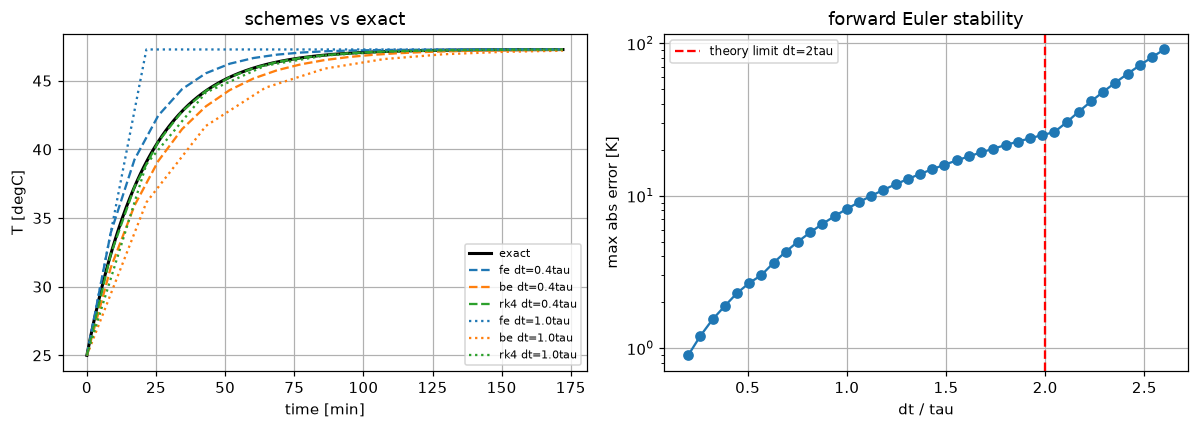

In [3]:
C = rho_cell * cp_cell * V_cell        # J/K   lump heat capacity
h_conv = 25.0
UA = h_conv * A_faces                  # W/K
tau = C / UA
Qgen = 15.0                            # W   steady internal heat
Tinf = 25.0
Tss = Tinf + Qgen / UA
print(f"tau = {tau:.1f} s,  steady-state rise = {Tss - Tinf:.2f} K")

def exact(t):
    return Tss + (Tinf - Tss) * np.exp(-t / tau)

def integrate(dt, method):
    t_end = 8 * tau
    n = int(t_end / dt)
    T = np.empty(n + 1)
    T[0] = Tinf
    for i in range(n):
        f = lambda Tv: (Qgen - UA * (Tv - Tinf)) / C
        if method == "fe":
            T[i + 1] = T[i] + dt * f(T[i])
        elif method == "be":
            # linear -> solve directly:  T1 = T0 + dt*(Qgen - UA*(T1-Tinf))/C
            T[i + 1] = (T[i] + dt * (Qgen + UA * Tinf) / C) / (1 + dt * UA / C)
        elif method == "rk4":
            k1 = f(T[i]); k2 = f(T[i] + dt / 2 * k1)
            k3 = f(T[i] + dt / 2 * k2); k4 = f(T[i] + dt * k3)
            T[i + 1] = T[i] + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return np.linspace(0, dt * n, n + 1), T

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tt = np.linspace(0, 8 * tau, 400)
ax[0].plot(tt / 60, exact(tt), "k", lw=2, label="exact")
for dt, ls in [(0.4 * tau, "--"), (1.0 * tau, ":")]:
    for m, c in [("fe", "C0"), ("be", "C1"), ("rk4", "C2")]:
        t, T = integrate(dt, m)
        ax[0].plot(t / 60, T, ls, color=c, label=f"{m} dt={dt/tau:.1f}tau")
ax[0].set(xlabel="time [min]", ylabel="T [degC]", title="schemes vs exact")
ax[0].legend(fontsize=7)

# stability sweep for forward Euler
dts = np.linspace(0.2, 2.6, 40) * tau
err = []
for dt in dts:
    t, T = integrate(dt, "fe")
    err.append(np.max(np.abs(T - exact(t))))
ax[1].axvline(2.0, color="r", ls="--", label="theory limit dt=2tau")
ax[1].semilogy(dts / tau, err, "o-")
ax[1].set(xlabel="dt / tau", ylabel="max abs error [K]",
          title="forward Euler stability")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [4]:
# Order-of-accuracy check: halve dt, see how the error drops.
print("global error vs dt (should be ~1st order for FE/BE, ~4th for RK4)")
prev = {}
for dt in [tau / 2, tau / 4, tau / 8, tau / 16]:
    row = []
    for m in ["fe", "be", "rk4"]:
        t, T = integrate(dt, m)
        e = np.max(np.abs(T - exact(t)))
        p = np.log2(prev[m] / e) if m in prev else np.nan
        prev[m] = e
        row.append(f"{m}: {e:.2e} (p={p:.2f})")
    print(f"dt={dt/tau:6.3f} tau | " + " | ".join(row))

global error vs dt (should be ~1st order for FE/BE, ~4th for RK4)
dt= 0.500 tau | fe: 2.63e+00 (p=nan) | be: 1.71e+00 (p=nan) | rk4: 6.49e-03 (p=nan)
dt= 0.250 tau | fe: 1.15e+00 (p=1.20) | be: 9.29e-01 (p=0.88) | rk4: 3.29e-04 (p=4.30)
dt= 0.125 tau | fe: 5.41e-01 (p=1.08) | be: 4.87e-01 (p=0.93) | rk4: 1.85e-05 (p=4.15)
dt= 0.062 tau | fe: 2.63e-01 (p=1.04) | be: 2.50e-01 (p=0.96) | rk4: 1.10e-06 (p=4.08)


**What this establishes**

* Forward Euler blows up almost exactly at $\Delta t = 2\tau$, as predicted.
* FE and BE converge at first order, RK4 at fourth order.
* BE is unconditionally stable but still only first-order accurate  -  stability
  is not accuracy.

This is why stiff system models (a fast electrical time constant sitting next to
a slow thermal one, e.g. a battery pack) use implicit solvers: the explicit step
limit would be set by the fastest mode even when I only care about the slow one.

## A3. 1-D steady conduction with internal generation

Plane wall, uniform volumetric generation $\dot q$, both faces held at $T_s$:

$$ k\frac{d^2T}{dx^2} + \dot q = 0
   \quad\Rightarrow\quad
   T(x) = T_s + \frac{\dot q}{2k}\left(\frac{L^2}{4} - x^2\right) $$

I solve the same problem with a second-order finite-difference scheme and a
tridiagonal solve, then check the grid-convergence order.

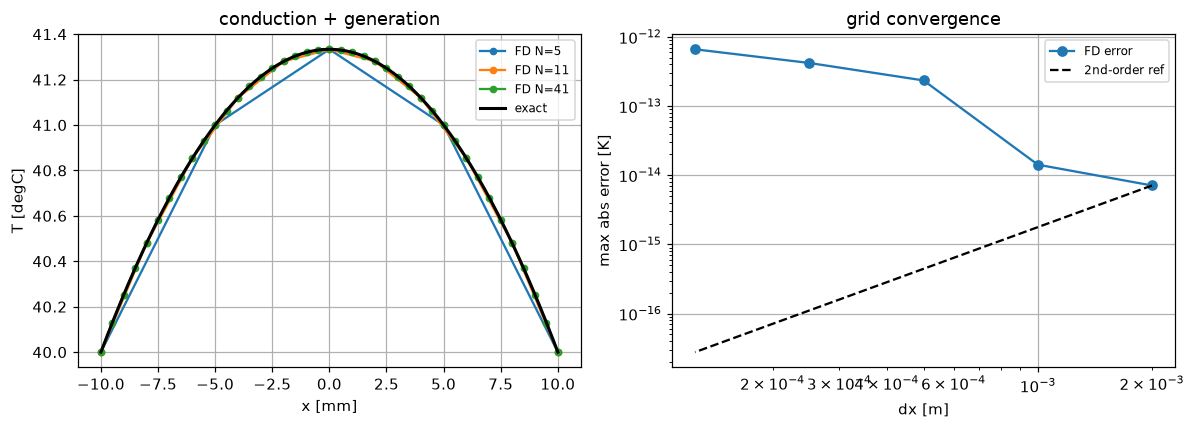

peak T  exact=41.333  FD(N=161)=41.333  diff=6.32e-13 K


In [5]:
L = 0.02
q_vol = 4.0e4
k_w = 1.5
Ts = 40.0

def fd_solve(N):
    x = np.linspace(-L / 2, L / 2, N)
    dx = x[1] - x[0]
    A = np.zeros((N, N)); b = np.zeros(N)
    A[0, 0] = A[-1, -1] = 1.0
    b[0] = b[-1] = Ts
    for i in range(1, N - 1):
        A[i, i - 1] = 1; A[i, i] = -2; A[i, i + 1] = 1
        b[i] = -q_vol * dx**2 / k_w
    return x, np.linalg.solve(A, b)

def Texact(x):
    return Ts + q_vol / (2 * k_w) * (L**2 / 4 - x**2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for N in [5, 11, 41]:
    x, T = fd_solve(N)
    ax[0].plot(x * 1e3, T, "o-", ms=4, label=f"FD N={N}")
xx = np.linspace(-L / 2, L / 2, 200)
ax[0].plot(xx * 1e3, Texact(xx), "k", lw=2, label="exact")
ax[0].set(xlabel="x [mm]", ylabel="T [degC]", title="conduction + generation")
ax[0].legend(fontsize=8)

Ns = [11, 21, 41, 81, 161]
errs = []
for N in Ns:
    x, T = fd_solve(N)
    errs.append(np.max(np.abs(T - Texact(x))))
ax[1].loglog([L / (N - 1) for N in Ns], errs, "o-", label="FD error")
ax[1].loglog([L / (N - 1) for N in Ns],
             [errs[0] * ((L / (N - 1)) / (L / (Ns[0] - 1)))**2 for N in Ns],
             "k--", label="2nd-order ref")
ax[1].set(xlabel="dx [m]", ylabel="max abs error [K]", title="grid convergence")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

peak = Texact(0.0)
xh, Th_ = fd_solve(161)
print(f"peak T  exact={peak:.3f}  FD(N=161)={Th_.max():.3f}  "
      f"diff={abs(peak - Th_.max()):.2e} K")

The finite-difference peak temperature matches the analytic value to well under
a milli-kelvin at N=161, and the error drops at second order with grid spacing.
That is the "validation before use" step: I trust the discretisation because it
reproduces a case with a known answer.

---
# Running log

| date | change |
|---|---|
| 2026-09-03 | Created (split out of the old combined notebook). A1 Biot/Fourier + lumped-assumption check, A2 forward/backward Euler + RK4 stability and order, A3 1-D conduction with generation vs analytic + grid convergence. |